# Differensiallikninger og fartslover

```{admonition} Læringsutbytte
Etter å ha arbeidet med dette temaet, skal du kunne:

1. forklare hvordan en differensiallikning beskriver endringen i et dynamisk system
2. utlede og implementere Forward Euler
3. modellere enkle og koblede kjemiske fartslover
4. undersøke hvordan tidssteg påvirker numerisk feil og stabilitet
5. bruke `solve_ivp` til å løse initialverdiproblemer
6. kontrollere en simulering med analytiske løsninger, stoffbalanse og kjemisk rimelighet
```

## Motivasjon

Eksperimenter står helt sentralt i kjemi, men simuleringer har blitt et viktig supplement. En simulering kan hjelpe oss å undersøke hvordan et kjemisk system utvikler seg når vi endrer en parameter, teste en modell mot eksperimentelle data eller studere systemer som er vanskelige å følge direkte.

Ofte kjenner vi ikke et ferdig uttrykk for utviklingen, men vi kjenner **endringen**. Et klassisk eksempel er en fartslov. For en førsteordens reaksjon

$$\mathrm{A\rightarrow produkter}$$

har vi

$$\frac{d[A]}{dt}=-k[A].$$

Likningen forteller hvordan konsentrasjonen endrer seg akkurat nå. Oppgaven vår er å bruke denne informasjonen til å finne hele utviklingen $[A](t)$.

## Hva er en differensiallikning?

En differensiallikning er en likning som inneholder en ukjent funksjon og én eller flere av de deriverte til funksjonen. Du kan møte mange skrivemåter:

$$y'=y$$

$$y'=t-y$$

$$u'(t)=u(t)$$

eller mer generelt

$$y'(t)=\frac{dy}{dt}=f(t,y).$$

Felles for dem er at venstresiden beskriver **endringen**, mens høyresiden forteller hva endringen avhenger av.

Når vi løser en vanlig algebraisk likning, leter vi etter et tall. Når vi løser en differensiallikning, leter vi etter en **funksjon** eller, numerisk, en rekke funksjonsverdier.

### Hvorfor trenger vi en startverdi?

Ta den svært enkle differensiallikningen

$$y'=1.$$

Hvis vi integrerer, får vi

$$y=t+C.$$

Det finnes altså uendelig mange løsninger – én for hver verdi av konstanten $C$. Hvis vi i tillegg vet at

$$y(0)=2,$$

blir $C=2$, og vi får én bestemt løsning. En slik opplysning kalles en **initialbetingelse**.

I kjemi kan initialbetingelsen for eksempel være startkonsentrasjonen $[A](0)$.

## Fra den deriverte til Eulers metode

Vi kjenner framoverdifferansen fra numerisk derivasjon:

$$\frac{dy}{dt}\approx\frac{y(t+\Delta t)-y(t)}{\Delta t}.$$

Nå bruker vi den på en litt annen måte. Vi kjenner $y(t)$ og uttrykket for den deriverte $dy/dt$, og ønsker å finne **neste verdi**, $y(t+\Delta t)$.

Vi ganger først med $\Delta t$:

$$\frac{dy}{dt}\Delta t\approx y(t+\Delta t)-y(t).$$

Så flytter vi $y(t)$ over på den andre siden:

$$y(t+\Delta t)\approx y(t)+\frac{dy}{dt}\Delta t.$$

Skriver vi differensiallikningen som $dy/dt=f(t,y)$ og bruker indekser, får vi

$$y_{n+1}=y_n+f(t_n,y_n)\Delta t.$$

Dette er **Forward Euler**. Legg merke til koblingen til forrige kapittel: Vi har gjort en kontinuerlig differensiallikning om til en **differenslikning** som datamaskinen kan gjenta steg for steg.


## Førsteordens reaksjon med Euler

Vi bruker

$$\frac{d[A]}{dt}=-k[A].$$

Før vi lager en generell Euler-funksjon, skriver vi ut algoritmen direkte. Da blir sammenhengen mellom fartsloven og koden tydeligst.


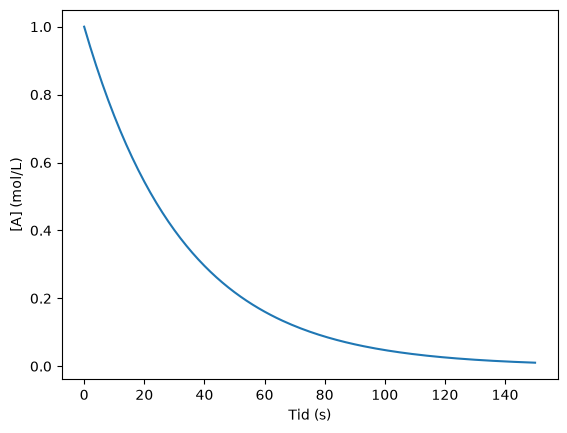

In [1]:
import numpy as np
import matplotlib.pyplot as plt

k = 0.030       # s^-1
A = 1.00        # mol/L
t = 0.0         # s
dt = 1.0        # s
t_slutt = 150.0

tid = [t]
konsentrasjon = [A]

while t < t_slutt:
    dA_dt = -k*A
    A = A + dA_dt*dt
    t = t + dt

    tid.append(t)
    konsentrasjon.append(A)

plt.plot(tid, konsentrasjon)
plt.xlabel("Tid (s)")
plt.ylabel("[A] (mol/L)")
plt.show()


Linjen

`A = A + dA_dt*dt`

**er Eulers metode**. Alt det andre i programmet setter startverdier, holder styr på tiden og lagrer resultatene slik at vi kan plotte dem.

Når vi har forstått denne løkken, kan vi pakke Euler-algoritmen inn i en funksjon. Da skiller vi selve løsningsmetoden fra den konkrete kjemiske modellen.


In [2]:
def euler(f, y0, t0, t_slutt, dt):
    t = t0
    y = y0
    tid = [t]
    verdier = [y]

    while t < t_slutt:
        y = y + f(t, y)*dt
        t = t + dt

        tid.append(t)
        verdier.append(y)

    return np.array(tid), np.array(verdier)


def forste_orden(t, A):
    return -k*A

A0 = 1.00
tid, A_euler = euler(forste_orden, A0, 0, 150, 1.0)


Denne førsteordens reaksjonen har også en analytisk løsning,

$$[A](t)=[A]_0e^{-kt}.$$

Det gjør den spesielt nyttig når vi lærer en numerisk metode: Vi kan kontrollere resultatet mot en kjent løsning.


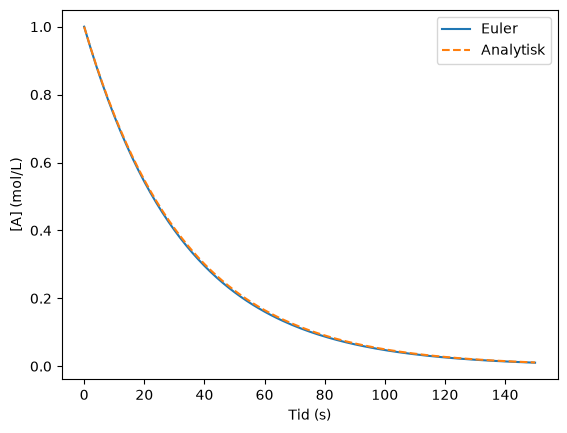

Største absolutte feil: 0.005588366753556284


In [3]:
A_analytisk = A0*np.exp(-k*tid)

plt.plot(tid, A_euler, label="Euler")
plt.plot(tid, A_analytisk, "--", label="Analytisk")
plt.xlabel("Tid (s)")
plt.ylabel("[A] (mol/L)")
plt.legend()
plt.show()

print("Største absolutte feil:", np.max(np.abs(A_euler - A_analytisk)))


## Hvor stort tidssteg bør vi bruke?

Euler antar at stigningen vi har **nå**, er en god tilnærming gjennom hele neste tidssteg. Hvis tidssteget er stort og systemet endrer seg raskt, blir denne antakelsen dårlig.

Vi undersøker derfor ikke bare én verdi av $\Delta t$. Et viktig numerisk kontrollspørsmål er:

> Endrer løsningen seg vesentlig hvis vi reduserer tidssteget?


In [4]:
for dt_test in [10.0, 5.0, 1.0, 0.2]:
    t_test, A_test = euler(forste_orden, A0, 0, 150, dt_test)
    A_eksakt = A0*np.exp(-k*t_test[-1])
    feil = abs(A_test[-1] - A_eksakt)
    print(f"dt = {dt_test:4.1f} s   feil ved slutt = {feil:.3e}")


dt = 10.0 s   feil ved slutt = 6.361e-03
dt =  5.0 s   feil ved slutt = 3.478e-03
dt =  1.0 s   feil ved slutt = 7.394e-04
dt =  0.2 s   feil ved slutt = 1.496e-04


### Prøv selv

Endre ratekonstanten og tidssteget, og undersøk når Euler gir en god tilnærming.

<iframe src="../../basthon/?from=examples/differensiallikning_euler_reaksjon.py" width="100%" height="640" frameborder="0" title="Prøv selv: Euler og reaksjonskinetikk" loading="lazy" allowfullscreen></iframe>

## Koblede fartslover

Mange kjemiske systemer inneholder flere konsentrasjoner som utvikler seg samtidig. For den irreversible reaksjonen

$$\mathrm{A+B\rightarrow C}$$

med fart

$$r=k[A][B]$$

får vi

$$\frac{d[A]}{dt}=-k[A][B],$$

$$\frac{d[B]}{dt}=-k[A][B],$$

$$\frac{d[C]}{dt}=k[A][B].$$

De tre likningene er **koblet** fordi den samme reaksjonsfarten avhenger av både $[A]$ og $[B]$.


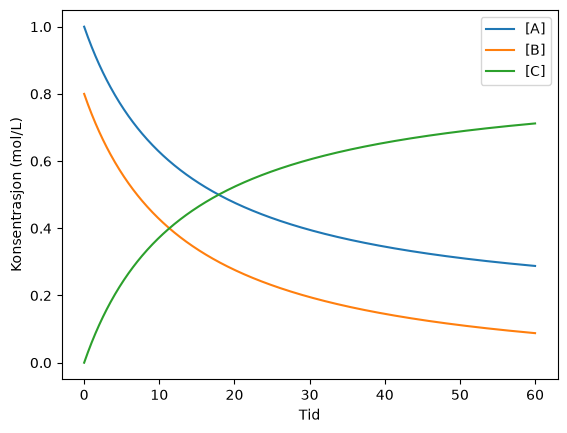

In [5]:
k = 0.08
dt = 0.1
t = np.arange(0, 60 + dt, dt)

A = np.zeros(len(t))
B = np.zeros(len(t))
C_prod = np.zeros(len(t))

A[0] = 1.00
B[0] = 0.80
C_prod[0] = 0.00

for n in range(len(t) - 1):
    rate = k*A[n]*B[n]

    A[n + 1] = A[n] - rate*dt
    B[n + 1] = B[n] - rate*dt
    C_prod[n + 1] = C_prod[n] + rate*dt

plt.plot(t, A, label="[A]")
plt.plot(t, B, label="[B]")
plt.plot(t, C_prod, label="[C]")
plt.xlabel("Tid")
plt.ylabel("Konsentrasjon (mol/L)")
plt.legend()
plt.show()


### Kontroller kjemien: stoffbalanse

Et numerisk program er ikke validert bare fordi grafen ser pen ut. For reaksjonen over skal

$$[A]+[C]=[A]_0$$

og

$$[B]+[C]=[B]_0$$

så lenge modellen bare inneholder denne ene reaksjonen.


In [6]:
balanse_A = A + C_prod
balanse_B = B + C_prod

print("Største avvik i A-balansen:", np.max(np.abs(balanse_A - A[0])))
print("Største avvik i B-balansen:", np.max(np.abs(balanse_B - B[0])))


Største avvik i A-balansen: 4.440892098500626e-16
Største avvik i B-balansen: 5.551115123125783e-16


## Reversibel reaksjon og dynamisk likevekt

For

$$\mathrm{A\rightleftharpoons B}$$

kan vi skrive

$$\frac{d[A]}{dt}=-k_f[A]+k_b[B],$$

$$\frac{d[B]}{dt}=k_f[A]-k_b[B].$$

Når systemet når dynamisk likevekt, blir nettoendringen null selv om framover- og bakoverreaksjonene fortsatt inngår i modellen.


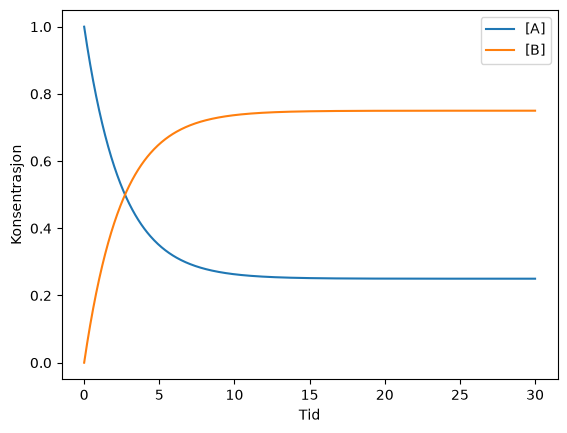

A + B ved slutten: 1.0000000000000018
B/A ved slutten: 2.9999347140732855


In [7]:
k_f = 0.30
k_b = 0.10
dt = 0.05
t = np.arange(0, 30 + dt, dt)

A = np.zeros(len(t))
B = np.zeros(len(t))
A[0] = 1.0

for n in range(len(t) - 1):
    netto = k_f*A[n] - k_b*B[n]
    A[n + 1] = A[n] - netto*dt
    B[n + 1] = B[n] + netto*dt

plt.plot(t, A, label="[A]")
plt.plot(t, B, label="[B]")
plt.xlabel("Tid")
plt.ylabel("Konsentrasjon")
plt.legend()
plt.show()

print("A + B ved slutten:", A[-1] + B[-1])
print("B/A ved slutten:", B[-1]/A[-1])


## Metoder av høyere orden: RK4

Forward Euler er en metode av første orden. **Orden** beskriver hvordan den numeriske feilen avtar når steglengden reduseres; den betyr ikke bare hvor mange ganger funksjonen evalueres.

Den klassiske Runge–Kutta-metoden RK4 bruker fire mellomliggende stigninger i hvert steg og har global feil som avtar omtrent som $\Delta t^4$ når forutsetningene er oppfylt. Metoden er derfor langt mer presis enn Euler for mange glatte problemer.


In [8]:
def rk4_steg(f, t, y, dt):
    k1 = f(t, y)
    k2 = f(t + dt/2, y + dt*k1/2)
    k3 = f(t + dt/2, y + dt*k2/2)
    k4 = f(t + dt, y + dt*k3)

    return y + dt*(k1 + 2*k2 + 2*k3 + k4)/6

def dy_dt(t, y):
    return -0.15*y

y = 1.0
t0 = 0.0
dt = 1.0

for n in range(10):
    y = rk4_steg(dy_dt, t0 + n*dt, y, dt)

print("RK4 etter 10 tidsenheter:", y)
print("Analytisk:", np.exp(-0.15*10))


RK4 etter 10 tidsenheter: 0.2231317605083842
Analytisk: 0.22313016014842982


## `solve_ivp`: ferdige ODE-løsere

I praktisk arbeid bruker vi vanligvis testede ODE-løsere. `scipy.integrate.solve_ivp` løser initialverdiproblemer og kan selv tilpasse tidssteg for å holde feilen under valgte toleranser.

Standardmetoden er `RK45`, en adaptiv Runge–Kutta-metode som bruker et innebygd par av femte og fjerde orden. Femteordensformelen brukes til selve steget, mens forskjellen mellom de to ordenene brukes til å anslå feilen og styre steglengden.


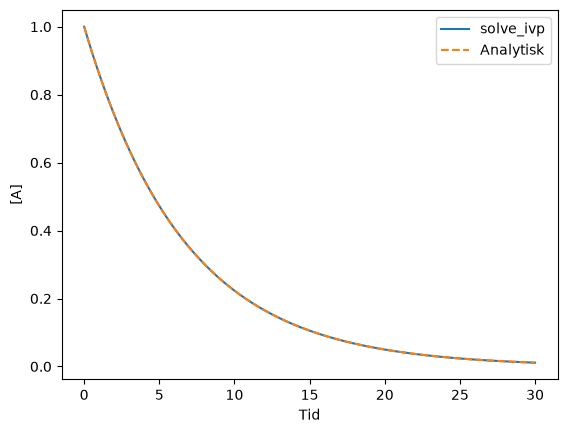

In [9]:
from scipy.integrate import solve_ivp

def forste_orden(t, y):
    return -0.15*y

t_eval = np.linspace(0, 30, 200)

losning = solve_ivp(forste_orden, [0, 30], [1.0], t_eval=t_eval, rtol=1e-8, atol=1e-10)

plt.plot(losning.t, losning.y[0], label="solve_ivp")
plt.plot(t_eval, np.exp(-0.15*t_eval), "--", label="Analytisk")
plt.xlabel("Tid")
plt.ylabel("[A]")
plt.legend()
plt.show()


## Stive differensiallikninger

Noen systemer inneholder prosesser på svært ulike tidsskalaer. Da kan eksplisitte metoder som Euler eller RK45 måtte bruke svært små tidssteg for å være stabile, selv om den langsomme delen av løsningen utvikler seg rolig. Slike problemer kalles ofte **stive**.

Kjemisk kinetikk kan bli stiv når noen reaksjoner er svært raske og andre svært langsomme. `solve_ivp` har implisitte metoder som `BDF` og `Radau` som er laget for slike problemer.

Vi skal ikke implementere disse metodene selv, men det er nyttig å kjenne igjen hvorfor en annen løser kan være nødvendig.


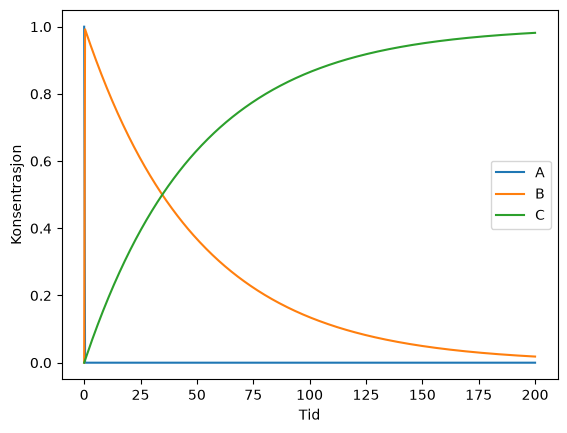

In [10]:
def konsekutive_reaksjoner(t, y):
    A, B, C = y
    k1 = 100.0
    k2 = 0.02

    dA = -k1*A
    dB = k1*A - k2*B
    dC = k2*B
    return [dA, dB, dC]

t_eval = np.linspace(0, 200, 500)

stiv = solve_ivp(konsekutive_reaksjoner, [0, 200], [1.0, 0.0, 0.0], t_eval=t_eval, method="BDF")

plt.plot(stiv.t, stiv.y[0], label="A")
plt.plot(stiv.t, stiv.y[1], label="B")
plt.plot(stiv.t, stiv.y[2], label="C")
plt.xlabel("Tid")
plt.ylabel("Konsentrasjon")
plt.legend()
plt.show()


```{admonition} En god simuleringsvane
:class: important
Når du løser en kjemisk differensiallikning numerisk, bør du spørre:

1. Har jeg formulert riktige fartslover og støkiometriske fortegn?
2. Er enhetene konsistente?
3. Endrer løsningen seg mye hvis jeg strammer inn toleransen eller reduserer tidssteget?
4. Bevares stoffmengde eller andre størrelser som modellen sier skal bevares?
5. Stemmer grensetilfellene med kjemisk intuisjon?
```

## Kort oppsummering

- En differensiallikning beskriver sammenhengen mellom tilstanden og endringen i et system.
- $f'(t)$ og $df/dt$ er to notasjoner for den deriverte.
- Euler lager en diskret differenslikning fra en kontinuerlig endringsrate.
- Koblede fartslover må oppdateres konsistent med støkiometrien.
- RK4 er en fjerdeordens metode; «orden» beskriver feilskalering, ikke bare antall funksjonsevalueringer.
- `solve_ivp` er det naturlige verktøyet for praktiske ODE-problemer.
- Stive systemer kan kreve metoder som BDF eller Radau.
- Numeriske resultater bør kontrolleres med kjemiske bevaringslover og konvergens.


## Oppgaver

```{admonition} Oppgave 1 – Euler og analytisk løsning
:class: tip
Løs $d[A]/dt=-0.20[A]$ med $[A](0)=1.50$ mol/L med Euler. Sammenlikn med den analytiske løsningen etter 5, 10 og 20 tidsenheter.
```

```{admonition} Oppgave 2 – tidssteg
:class: tip
Gjenta oppgave 1 med $\Delta t=2.0$, 1.0, 0.5, 0.1 og 0.01. Lag et plott av feilen ved $t=20$ som funksjon av $\Delta t$.
```

```{admonition} Oppgave 3 – koblet reaksjon
:class: tip
Simuler $\mathrm{A+B\rightarrow C}$ med $k=0.05$, $[A]_0=1.00$ M og $[B]_0=0.60$ M. Kontroller at $[A]+[C]$ og $[B]+[C]$ er konstante.
```

```{admonition} Oppgave 4 – reversibel reaksjon
:class: tip
For $\mathrm{A\rightleftharpoons B}$ bruker du $k_f=0.40$ og $k_b=0.10$. Start med bare A. Simuler til systemet er nær likevekt, og sammenlikn det numeriske forholdet $[B]/[A]$ med $k_f/k_b$.
```

```{admonition} Oppgave 5 – Euler mot RK4
:class: tip
Bruk samme relativt store tidssteg til å løse en førsteordens reaksjon med Euler og RK4. Sammenlikn begge med den analytiske løsningen.
```

```{admonition} Oppgave 6 – `solve_ivp`
:class: tip
Løs den førsteordens reaksjonen med `solve_ivp`. Undersøk feltene `success`, `message` og antall funksjonsevalueringer `nfev`. Hva forteller de deg?
```

```{admonition} Oppgave 7 – konsekutive reaksjoner
:class: tip
Modeller $\mathrm{A\rightarrow B\rightarrow C}$ med to ulike ratekonstanter. Finn tidspunktet der $[B]$ er størst. Forklar kjemisk hvorfor mellomproduktet først øker og deretter avtar.
```

```{admonition} Oppgave 8 – stivt system
:class: tip
Bruk modellen med $k_1=100$ og $k_2=0.02$. Løs den med `RK45` og `BDF` med samme toleranser. Sammenlikn `nfev` og kommenter forskjellen.
```


## Videoer

````{tab-set}
```{tab-item} Differensiallikninger
<iframe width="850" height="450" src="https://www.youtube.com/embed/O08ToTAqp5w" title="Differensiallikninger" frameborder="0" allowfullscreen></iframe>
```
```{tab-item} Fartslover (ratelover)
<iframe width="850" height="450" src="https://www.youtube.com/embed/Ql-68OsKDaQ" title="Fartslover" frameborder="0" allowfullscreen></iframe>
```
````
